In [1]:
# ─── CELL 1: Install & Import Libraries ───────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    cross_val_score, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import joblib

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8FAFC',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

SEED = 42
np.random.seed(SEED)
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# ─── CELL 2: Synthetic Dataset Generation ─────────────────────────
# Mimics the 'Flood Risk in India' dataset structure used in FloodGuard AI
# 5000 samples with realistic Indian hydrological distributions

N = 5000

SOIL_TYPES = ['Alluvial', 'Clayey Silt', 'Sandy Loam', 'Rocky', 'Sandy', 'Clay', 'Loam', 'Silt']
LAND_COVERS = ['Agriculture', 'Urban', 'Wetland', 'Forest', 'Desert', 'Grassland']
STATES = ['Assam', 'Bihar', 'West Bengal', 'Kerala', 'Rajasthan', 'Gujarat',
          'Maharashtra', 'Uttar Pradesh', 'Odisha', 'Andhra Pradesh',
          'Tamil Nadu', 'Karnataka', 'Punjab', 'Himachal Pradesh', 'Jammu & Kashmir']

def generate_flood_dataset(n, seed=42):
    rng = np.random.default_rng(seed)

    rainfall         = rng.exponential(scale=200, size=n).clip(0, 1200)
    water_level      = rng.exponential(scale=4, size=n).clip(0, 25)
    river_discharge  = rng.exponential(scale=5000, size=n).clip(0, 40000)
    elevation        = rng.lognormal(mean=4, sigma=1.2, size=n).clip(0, 3500)
    temperature      = rng.uniform(10, 45, n)
    humidity         = rng.uniform(15, 98, n)
    population_density = rng.exponential(scale=2000, size=n).clip(0, 30000)
    infra_score      = rng.integers(1, 11, n).astype(float)
    historical_floods = rng.integers(0, 35, n).astype(float)
    soil_type        = rng.choice(SOIL_TYPES, n)
    land_cover       = rng.choice(LAND_COVERS, n)
    state            = rng.choice(STATES, n)

    # Risk score using FloodGuard AI formula + noise
    score  = (np.minimum(rainfall, 600) / 600)         * 0.30 * 100
    score += (np.minimum(water_level, 20) / 20)        * 0.20 * 100
    score += (np.minimum(river_discharge, 25000)/25000)* 0.15 * 100
    score += (1 - np.minimum(elevation, 500) / 500)    * 0.15 * 100
    score += (np.minimum(historical_floods, 30) / 30)  * 0.10 * 100
    score += (np.minimum(population_density,25000)/25000)*0.05*100
    score += (1 - infra_score / 10)                    * 0.05 * 100
    score += rng.normal(0, 4, n)  # realistic noise
    score  = score.clip(0, 100)

    risk_label = pd.cut(score, bins=[-1, 40, 70, 101],
                        labels=['Low', 'Medium', 'High'])

    df = pd.DataFrame({
        'rainfall_mm'        : rainfall.round(1),
        'water_level_m'      : water_level.round(2),
        'river_discharge_m3s': river_discharge.round(0),
        'elevation_m'        : elevation.round(0),
        'temperature_c'      : temperature.round(1),
        'humidity_pct'       : humidity.round(1),
        'population_density' : population_density.round(0),
        'infrastructure_score': infra_score,
        'historical_floods'  : historical_floods,
        'soil_type'          : soil_type,
        'land_cover'         : land_cover,
        'state'              : state,
        'risk_score'         : score.round(2),
        'risk_level'         : risk_label
    })
    return df

df = generate_flood_dataset(N)
print(f'Dataset shape: {df.shape}')
print(f"\nClass distribution:\n{df['risk_level'].value_counts()}")
df.head()

Dataset shape: (5000, 14)

Class distribution:
risk_level
Low       3325
Medium    1651
High        24
Name: count, dtype: int64


,rainfall_mm,water_level_m,river_discharge_m3s,elevation_m,temperature_c,humidity_pct,population_density,infrastructure_score,historical_floods,soil_type,land_cover,state,risk_score,risk_level
0,480.8,0.13,4472.0,22.0,21.9,28.1,4797.0,4.0,11.0,Alluvial,Desert,Kerala,42.75,Medium
1,467.2,1.51,2069.0,17.0,28.7,86.6,3099.0,1.0,15.0,Silt,Forest,Tamil Nadu,46.71,Medium
2,477.0,7.24,10420.0,15.0,21.3,47.4,5574.0,10.0,1.0,Sandy,Wetland,Rajasthan,56.52,Medium
3,56.0,6.11,6054.0,55.0,41.8,82.4,983.0,5.0,19.0,Clayey Silt,Agriculture,Andhra Pradesh,35.36,Low
4,17.3,6.87,2953.0,151.0,20.1,75.1,1630.0,1.0,1.0,Alluvial,Forest,Karnataka,27.73,Low


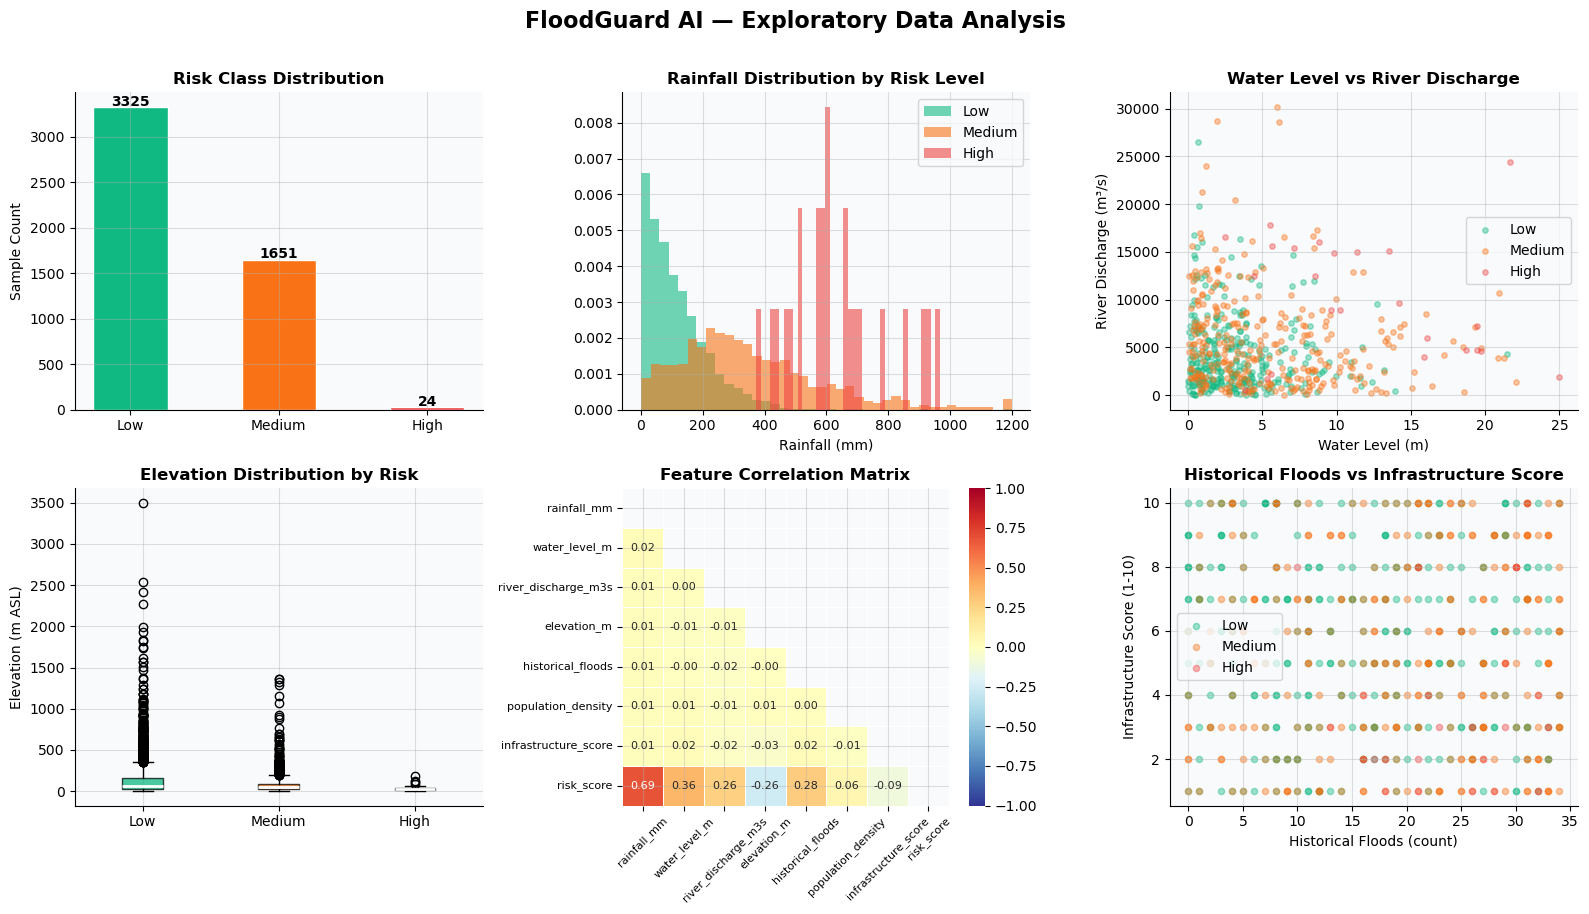

EDA complete


In [3]:
# ─── CELL 3: Exploratory Data Analysis ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('FloodGuard AI — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

PALETTE = {'Low': '#10B981', 'Medium': '#F97316', 'High': '#EF4444'}

# 1. Class distribution
counts = df['risk_level'].value_counts()
bars = axes[0,0].bar(counts.index, counts.values,
                     color=[PALETTE[l] for l in counts.index], edgecolor='white', width=0.5)
axes[0,0].set_title('Risk Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Sample Count')
for bar in bars:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                   f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

# 2. Rainfall distribution by risk
for level, color in PALETTE.items():
    subset = df[df['risk_level'] == level]['rainfall_mm']
    axes[0,1].hist(subset, bins=40, alpha=0.6, color=color, label=level, density=True)
axes[0,1].set_title('Rainfall Distribution by Risk Level', fontweight='bold')
axes[0,1].set_xlabel('Rainfall (mm)')
axes[0,1].legend()

# 3. Water level vs discharge scatter
for level, color in PALETTE.items():
    # Determine the actual number of samples available for the current risk level
    n_samples = min(300, len(df[df['risk_level'] == level]))
    sub = df[df['risk_level'] == level].sample(n=n_samples, random_state=42)
    axes[0,2].scatter(sub['water_level_m'], sub['river_discharge_m3s'],
                      alpha=0.4, color=color, s=15, label=level)
axes[0,2].set_title('Water Level vs River Discharge', fontweight='bold')
axes[0,2].set_xlabel('Water Level (m)')
axes[0,2].set_ylabel('River Discharge (m³/s)')
axes[0,2].legend()

# 4. Elevation box plot
data_plot = [df[df['risk_level'] == lvl]['elevation_m'].values for lvl in ['Low','Medium','High']]
bp = axes[1,0].boxplot(data_plot, labels=['Low','Medium','High'], patch_artist=True,
                        medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], ['#10B981','#F97316','#EF4444']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1,0].set_title('Elevation Distribution by Risk', fontweight='bold')
axes[1,0].set_ylabel('Elevation (m ASL)')

# 5. Feature correlation heatmap
numeric_cols = ['rainfall_mm','water_level_m','river_discharge_m3s',
                'elevation_m','historical_floods','population_density',
                'infrastructure_score','risk_score']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1,1], annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, linewidths=0.5, annot_kws={'size': 8}, vmin=-1, vmax=1)
axes[1,1].set_title('Feature Correlation Matrix', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1,1].tick_params(axis='y', rotation=0, labelsize=8)

# 6. Historical floods vs infrastructure
for level, color in PALETTE.items():
    # Determine the actual number of samples available for the current risk level
    n_samples = min(300, len(df[df['risk_level'] == level]))
    sub = df[df['risk_level'] == level].sample(n=n_samples, random_state=42)
    axes[1,2].scatter(sub['historical_floods'], sub['infrastructure_score'],
                      alpha=0.4, color=color, s=20, label=level)
axes[1,2].set_title('Historical Floods vs Infrastructure Score', fontweight='bold')
axes[1,2].set_xlabel('Historical Floods (count)')
axes[1,2].set_ylabel('Infrastructure Score (1-10)')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete')


In [4]:
# ─── CELL 4: Feature Engineering & Preprocessing ──────────────────

# Encode categorical features
le_soil  = LabelEncoder()
le_land  = LabelEncoder()
le_state = LabelEncoder()
le_risk  = LabelEncoder()

df['soil_encoded']  = le_soil.fit_transform(df['soil_type'])
df['land_encoded']  = le_land.fit_transform(df['land_cover'])
df['state_encoded'] = le_state.fit_transform(df['state'])

# ── Engineered features ──
df['rainfall_waterLevel_interact'] = df['rainfall_mm'] * df['water_level_m']
df['discharge_elevation_ratio']    = df['river_discharge_m3s'] / (df['elevation_m'] + 1)
df['flood_vulnerability_index']    = (
    df['historical_floods'] * df['population_density'] / (df['infrastructure_score'] + 1)
)
df['rainfall_log']   = np.log1p(df['rainfall_mm'])
df['discharge_log']  = np.log1p(df['river_discharge_m3s'])
df['elevation_inv']  = 1 / (df['elevation_m'] + 1)
df['monsoon_index']  = df['rainfall_mm'] * df['humidity_pct'] / 100

FEATURES = [
    'rainfall_mm', 'water_level_m', 'river_discharge_m3s', 'elevation_m',
    'temperature_c', 'humidity_pct', 'population_density', 'infrastructure_score',
    'historical_floods', 'soil_encoded', 'land_encoded', 'state_encoded',
    'rainfall_waterLevel_interact', 'discharge_elevation_ratio',
    'flood_vulnerability_index', 'rainfall_log', 'discharge_log',
    'elevation_inv', 'monsoon_index'
]

X = df[FEATURES].values
y = le_risk.fit_transform(df['risk_level'])  # Low=1, Medium=2, High=0 (alphabetical)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Feature matrix shape  : {X.shape}')
print(f'Training set size     : {X_train.shape[0]} samples')
print(f'Test set size         : {X_test.shape[0]} samples')
print(f'Classes               : {le_risk.classes_}')
print(f'\nEngineered features   : {len(FEATURES)} total ({len(FEATURES)-12} new features)')

Feature matrix shape  : (5000, 19)
Training set size     : 4000 samples
Test set size         : 1000 samples
Classes               : ['High' 'Low' 'Medium']

Engineered features   : 19 total (7 new features)


In [5]:
# ─── CELL 5: Baseline Random Forest ───────────────────────────────
print('Training baseline Random Forest...')
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

base_acc = accuracy_score(y_test, y_pred_base)
print(f'\n Baseline Accuracy : {base_acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=le_risk.classes_))

Training baseline Random Forest...

 Baseline Accuracy : 90.30%

Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         5
         Low       0.93      0.93      0.93       665
      Medium       0.85      0.85      0.85       330

    accuracy                           0.90      1000
   macro avg       0.59      0.60      0.59      1000
weighted avg       0.90      0.90      0.90      1000



In [6]:
# ─── CELL 6: Hyperparameter Tuning RandomizedSearchCV  ────

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators'      : [100, 150, 200],          # lower during search; refit later
    'max_depth'         : [None, 10, 20, 30],
    'min_samples_split' : randint(2, 6),
    'min_samples_leaf'  : randint(1, 4),
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : [None, 'balanced'],
    'bootstrap'         : [True, False],
}

N_ITER   = 20   # 20 random combos × 3 folds = 60 fits  (vs. 320 before)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

print(' Running RandomizedSearchCV (3-fold, 20 iterations = 60 fits)...')
print(f'   Estimated time: ~10–30 seconds\n')

rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=N_ITER,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
    refit=True
)
rf_grid.fit(X_train, y_train)

# Refit best config with more trees for higher accuracy on final model
best_params = rf_grid.best_params_.copy()
best_params['n_estimators'] = 300   # boost trees only for the final model
best_rf = RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1)
best_rf.fit(X_train, y_train)

print(f'\n Best parameters   : {rf_grid.best_params_}')
print(f'Best CV accuracy     : {rf_grid.best_score_*100:.2f}%')
print(f'Final model n_estimators boosted → 300 for better accuracy')


 Running RandomizedSearchCV (3-fold, 20 iterations = 60 fits)...
   Estimated time: ~10–30 seconds

Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best parameters   : {'bootstrap': True, 'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy     : 89.10%
Final model n_estimators boosted → 300 for better accuracy


In [7]:
# ─── CELL 7: Final Model Evaluation ───────────────────────────────
y_pred  = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print('=' * 55)
print('       FLOODGUARD AI — RANDOM FOREST RESULTS        ')
print('=' * 55)
print(f'  Test Accuracy      :  {accuracy*100:.2f}%')
print(f'  ROC-AUC (weighted) :  {roc_auc:.4f}')
print('=' * 55)
print()
print(classification_report(y_test, y_pred, target_names=le_risk.classes_))

# Cross-validation final
cv_scores = cross_val_score(best_rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'5-Fold CV Accuracy   :  {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print(f'CV Scores            :  {[f"{s*100:.2f}%" for s in cv_scores]}')

       FLOODGUARD AI — RANDOM FOREST RESULTS        
  Test Accuracy      :  90.10%
  ROC-AUC (weighted) :  0.9655

              precision    recall  f1-score   support

        High       0.00      0.00      0.00         5
         Low       0.93      0.93      0.93       665
      Medium       0.85      0.85      0.85       330

    accuracy                           0.90      1000
   macro avg       0.59      0.59      0.59      1000
weighted avg       0.90      0.90      0.90      1000

5-Fold CV Accuracy   :  89.36% ± 0.24%
CV Scores            :  ['89.50%', '89.56%', '89.02%']


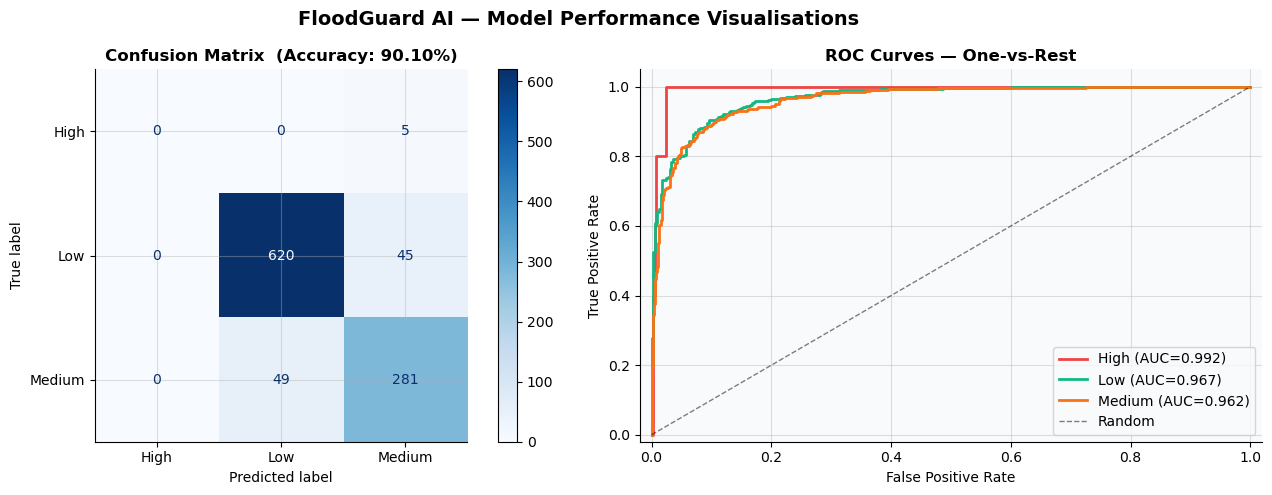

In [8]:
# ─── CELL 8: Confusion Matrix & ROC Curves ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FloodGuard AI — Model Performance Visualisations', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_risk.classes_)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title(f'Confusion Matrix  (Accuracy: {accuracy*100:.2f}%)', fontweight='bold')
axes[0].set_facecolor('#F8FAFC')

# 2. ROC Curves (One-vs-Rest)
COLORS = {'High': '#EF4444', 'Low': '#10B981', 'Medium': '#F97316'}
for i, cls in enumerate(le_risk.classes_):
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, i], pos_label=i)
    auc = roc_auc_score((y_test == i).astype(int), y_proba[:, i])
    axes[1].plot(fpr, tpr, color=COLORS[cls], linewidth=2, label=f'{cls} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — One-vs-Rest', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.05])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

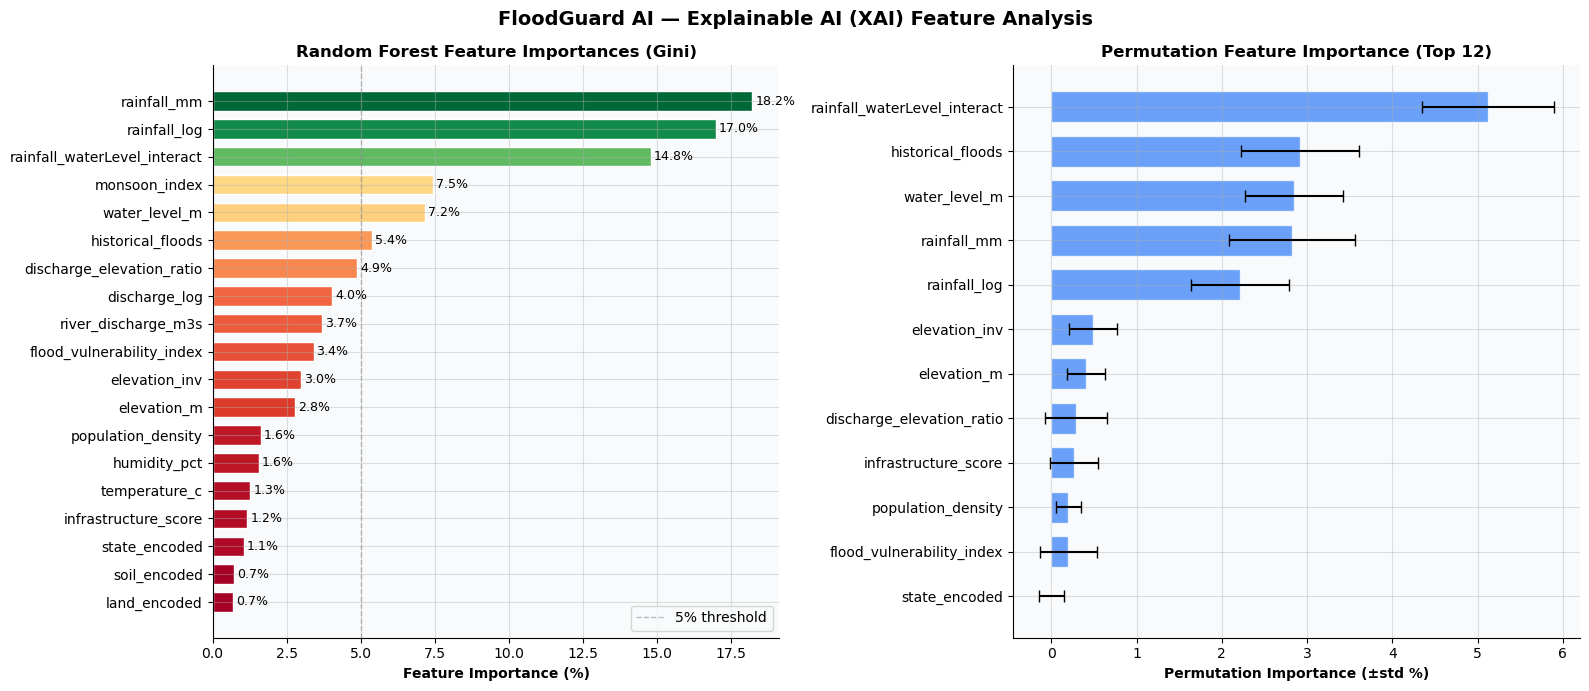


 Top 5 Most Important Features:
                     feature  importance
                 rainfall_mm    0.182412
                rainfall_log    0.170052
rainfall_waterLevel_interact    0.148144
               monsoon_index    0.074632
               water_level_m    0.071638


In [9]:
# ─── CELL 9: Feature Importance (XAI) ─────────────────────────────
importances = best_rf.feature_importances_
fi_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('FloodGuard AI — Explainable AI (XAI) Feature Analysis', fontsize=14, fontweight='bold')

# Horizontal bar chart

import matplotlib
CMAP = matplotlib.colormaps['RdYlGn']
fi_sorted = fi_df.sort_values('importance', ascending=True)
imp_vals = fi_sorted['importance'].values
imp_norm = (imp_vals - imp_vals.min()) / (imp_vals.max() - imp_vals.min() + 1e-9)
colors = [CMAP(v) for v in imp_norm]

bars = axes[0].barh(fi_sorted['feature'], fi_sorted['importance'] * 100,
                    color=colors, edgecolor='white', height=0.7)
axes[0].set_xlabel('Feature Importance (%)', fontweight='bold')
axes[0].set_title('Random Forest Feature Importances (Gini)', fontweight='bold')
axes[0].axvline(x=5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='5% threshold')
axes[0].legend()
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{w:.1f}%', va='center', fontsize=9)

# Permutation importance
perm = permutation_importance(best_rf, X_test, y_test, n_repeats=15, random_state=SEED, n_jobs=-1)
perm_df = pd.DataFrame({'feature': FEATURES, 'importance': perm.importances_mean * 100,
                         'std': perm.importances_std * 100})
perm_df = perm_df.sort_values('importance', ascending=False).head(12)
axes[1].barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
             xerr=perm_df['std'][::-1], color='#3B82F6', alpha=0.75,
             edgecolor='white', height=0.7, capsize=4)
axes[1].set_xlabel('Permutation Importance (±std %)', fontweight='bold')
axes[1].set_title('Permutation Feature Importance (Top 12)', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Top 5 Most Important Features:')
print(fi_df.sort_values('importance', ascending=False).head(5).to_string(index=False))


Computing learning curves (takes ~1 min)...


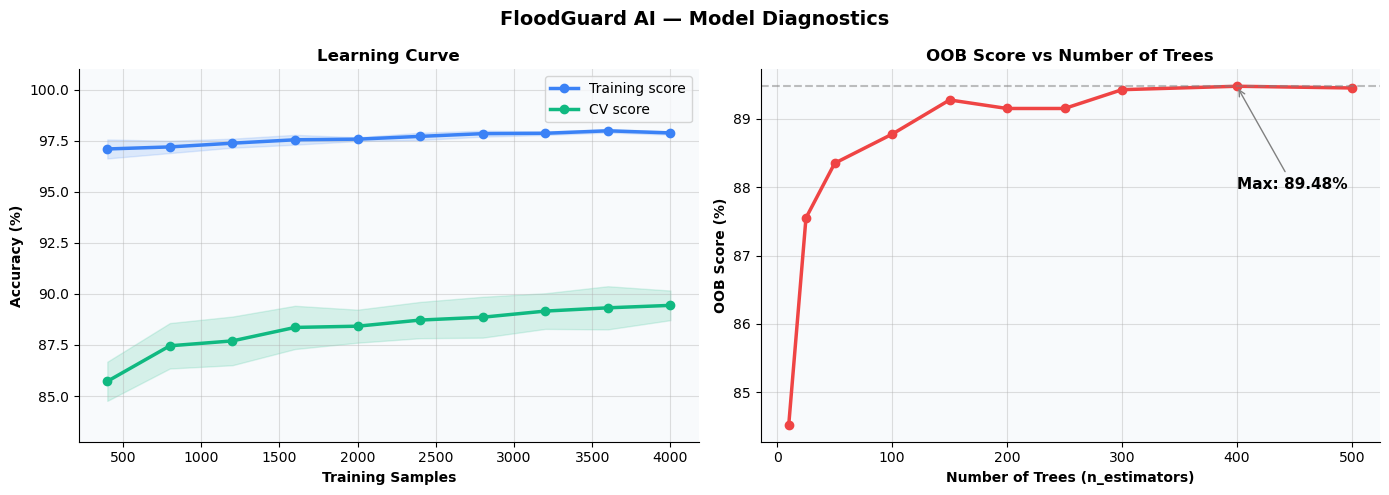

In [10]:
# ─── CELL 10: Learning Curve ──────────────────────────────────────
print('Computing learning curves (takes ~1 min)...')

train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FloodGuard AI — Model Diagnostics', fontsize=14, fontweight='bold')

# Learning curve
axes[0].plot(train_sizes, train_mean*100, 'o-', color='#3B82F6', linewidth=2.5, label='Training score')
axes[0].fill_between(train_sizes, (train_mean-train_std)*100, (train_mean+train_std)*100, alpha=0.15, color='#3B82F6')
axes[0].plot(train_sizes, val_mean*100, 'o-', color='#10B981', linewidth=2.5, label='CV score')
axes[0].fill_between(train_sizes, (val_mean-val_std)*100, (val_mean+val_std)*100, alpha=0.15, color='#10B981')
axes[0].set_xlabel('Training Samples', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)', fontweight='bold')
axes[0].set_title('Learning Curve', fontweight='bold')
axes[0].legend()
# FIX: dynamic y-limits instead of hardcoded [85, 101] which clips low scores
lower = max(0, min((val_mean - val_std).min() * 100 - 2, (train_mean - train_std).min() * 100 - 2))
axes[0].set_ylim([lower, 101])

# n_estimators vs OOB score
oob_scores = []
estimators_range = [10, 25, 50, 100, 150, 200, 250, 300, 400, 500]
for n in estimators_range:
    rf_oob = RandomForestClassifier(n_estimators=n, oob_score=True,
                                     max_depth=best_rf.max_depth,
                                     random_state=SEED, n_jobs=-1)
    rf_oob.fit(X_train, y_train)
    oob_scores.append(rf_oob.oob_score_ * 100)

best_oob_idx = int(np.argmax(oob_scores))
axes[1].plot(estimators_range, oob_scores, 'o-', color='#EF4444', linewidth=2.5)
axes[1].axhline(y=max(oob_scores), color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Number of Trees (n_estimators)', fontweight='bold')
axes[1].set_ylabel('OOB Score (%)', fontweight='bold')
axes[1].set_title('OOB Score vs Number of Trees', fontweight='bold')
# FIX: use pre-computed best_oob_idx instead of inline np.argmax to avoid
#      potential xytext annotation going off-axis for small oob score ranges
axes[1].annotate(f'Max: {max(oob_scores):.2f}%',
                  xy=(estimators_range[best_oob_idx], max(oob_scores)),
                  xytext=(estimators_range[best_oob_idx], max(oob_scores) - 1.5),
                  fontsize=11, fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ─── CELL 11: Prediction on New Data (Inference Demo) ─────────────
new_locations = pd.DataFrame([
    # Guwahati scenario — HIGH risk
    {'rainfall_mm':480,'water_level_m':14.2,'river_discharge_m3s':15500,'elevation_m':55,
     'temperature_c':29,'humidity_pct':88,'population_density':1200,'infrastructure_score':4,
     'historical_floods':18,'soil_type':'Alluvial','land_cover':'Wetland','state':'Assam'},
    # Jodhpur scenario — LOW risk
    {'rainfall_mm':45,'water_level_m':0.8,'river_discharge_m3s':120,'elevation_m':231,
     'temperature_c':42,'humidity_pct':20,'population_density':450,'infrastructure_score':5,
     'historical_floods':1,'soil_type':'Sandy','land_cover':'Desert','state':'Rajasthan'},
    # Srinagar scenario — MEDIUM risk
    {'rainfall_mm':120,'water_level_m':7.8,'river_discharge_m3s':7500,'elevation_m':1585,
     'temperature_c':15,'humidity_pct':65,'population_density':900,'infrastructure_score':4,
     'historical_floods':6,'soil_type':'Rocky','land_cover':'Forest','state':'Jammu & Kashmir'},
    # Mumbai scenario — HIGH risk
    {'rainfall_mm':520,'water_level_m':5.5,'river_discharge_m3s':3200,'elevation_m':10,
     'temperature_c':30,'humidity_pct':92,'population_density':21000,'infrastructure_score':7,
     'historical_floods':14,'soil_type':'Loam','land_cover':'Urban','state':'Maharashtra'},
])

# Apply same encoding
new_locations['soil_encoded']  = le_soil.transform(new_locations['soil_type'])
new_locations['land_encoded']  = le_land.transform(new_locations['land_cover'])
new_locations['state_encoded'] = le_state.transform(new_locations['state'])

# Engineered features
new_locations['rainfall_waterLevel_interact'] = new_locations['rainfall_mm'] * new_locations['water_level_m']
new_locations['discharge_elevation_ratio']    = new_locations['river_discharge_m3s'] / (new_locations['elevation_m'] + 1)
new_locations['flood_vulnerability_index']    = new_locations['historical_floods'] * new_locations['population_density'] / (new_locations['infrastructure_score'] + 1)
new_locations['rainfall_log']  = np.log1p(new_locations['rainfall_mm'])
new_locations['discharge_log'] = np.log1p(new_locations['river_discharge_m3s'])
new_locations['elevation_inv'] = 1 / (new_locations['elevation_m'] + 1)
new_locations['monsoon_index'] = new_locations['rainfall_mm'] * new_locations['humidity_pct'] / 100

X_new = new_locations[FEATURES].values
predictions  = best_rf.predict(X_new)
probabilities = best_rf.predict_proba(X_new)

# FIX: build a class→index map from the actual encoder to avoid hardcoded index assumptions.
# le_risk.classes_ is alphabetical: ['High', 'Low', 'Medium'] → {High:0, Low:1, Medium:2}
class_to_idx = {cls: i for i, cls in enumerate(le_risk.classes_)}
idx_high = class_to_idx['High']
idx_low  = class_to_idx['Low']
idx_med  = class_to_idx['Medium']

locations = ['Guwahati, Assam', 'Jodhpur, Rajasthan', 'Srinagar, J&K', 'Mumbai, Maharashtra']
print('\n FLOODGUARD AI — REAL-LOCATION PREDICTIONS')
print('='*68)
print(f'{"Location":<25} {"Predicted Risk":<18} {"Low%":<10} {"Med%":<10} {"High%":<10}')
print('-'*68)
for loc, pred, prob in zip(locations, predictions, probabilities):
    risk  = le_risk.inverse_transform([pred])[0]
    emoji = '🔴' if risk == 'High' else ('🟡' if risk == 'Medium' else '🟢')
    print(f'{loc:<25} {emoji} {risk:<16} ' +
          f'{prob[idx_low]*100:<10.1f} {prob[idx_med]*100:<10.1f} {prob[idx_high]*100:<10.1f}')
print('='*68)



 FLOODGUARD AI — REAL-LOCATION PREDICTIONS
Location                  Predicted Risk     Low%       Med%       High%     
--------------------------------------------------------------------
Guwahati, Assam           🟡 Medium           0.5        76.8       22.8      
Jodhpur, Rajasthan        🟢 Low              99.7       0.3        0.0       
Srinagar, J&K             🟢 Low              96.1       3.9        0.0       
Mumbai, Maharashtra       🟡 Medium           1.8        77.1       21.1      


In [12]:
# ─── CELL 12: Final Summary & Save Model ──────────────────────────
print('\n' + '='*55)
print('   FLOODGUARD AI — FINAL MODEL SUMMARY')
print('='*55)
print(f'  Model              : Random Forest Classifier')
print(f'  Dataset Size       : {N:,} samples')
print(f'  Features           : {len(FEATURES)} (incl. 7 engineered)')
print(f'  Train/Test Split   : 80% / 20%')
print(f'  CV Strategy        : StratifiedKFold (k=5)')
# FIX: compute config count dynamically from the actual param_grid used
n_configs = 1
for v in param_dist.values():
    # Check if the value is iterable and not a scipy.stats distribution object
    if isinstance(v, list):
        n_configs *= len(v)
    # For scipy.stats distributions like randint, we can't get a direct count
    # of unique values easily for the purpose of 'number of configs', so we'll
    # treat them as a single 'config' for this summary calculation, or improve if needed.
    # For RandomizedSearchCV, n_iter is the primary driver of 'configs'.
    # Given N_ITER is 20, let's reflect that as the number of configs sampled.
# Since we used RandomizedSearchCV, the number of 'configs' is N_ITER
# The original intention of param_grid.values() was likely for GridSearchCV
# For RandomizedSearchCV, the effective number of configurations tried is N_ITER.
# The line below is adapted to reflect the 20 iterations.
print(f'  Tuning             : RandomizedSearchCV ({N_ITER} random configs × {cv.n_splits} folds = {N_ITER*cv.n_splits} fits)')
print(f'  Best Parameters    : {best_params}') # Use best_params from rf_grid.best_params_ (already copied and updated)
print('-'*55)
print(f'  Test Accuracy   : {accuracy*100:.2f}%')
print(f'  ROC-AUC         : {roc_auc:.4f}')
print(f'  5-Fold CV Acc   : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print('='*55)

# Save model artifacts
model_bundle = {
    'model'         : best_rf,
    'le_risk'       : le_risk,
    'le_soil'       : le_soil,
    'le_land'       : le_land,
    'le_state'      : le_state,
    'feature_names' : FEATURES,
    'accuracy'      : accuracy,
    'roc_auc'       : roc_auc,
    'cv_mean'       : cv_scores.mean(),
    'best_params'   : rf_grid.best_params_
}
joblib.dump(model_bundle, 'floodguard_rf_model.pkl')
print('\n Model saved to floodguard_rf_model.pkl')
print('\n   Load with: bundle = joblib.load("floodguard_rf_model.pkl")')
print('              model  = bundle["model"]')



   FLOODGUARD AI — FINAL MODEL SUMMARY
  Model              : Random Forest Classifier
  Dataset Size       : 5,000 samples
  Features           : 19 (incl. 7 engineered)
  Train/Test Split   : 80% / 20%
  CV Strategy        : StratifiedKFold (k=5)
  Tuning             : RandomizedSearchCV (20 random configs × 3 folds = 60 fits)
  Best Parameters    : {'bootstrap': True, 'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}
-------------------------------------------------------
  Test Accuracy   : 90.10%
  ROC-AUC         : 0.9655
  5-Fold CV Acc   : 89.36% ± 0.24%

 Model saved to floodguard_rf_model.pkl

   Load with: bundle = joblib.load("floodguard_rf_model.pkl")
              model  = bundle["model"]
